#

## Ход работы

**О датасете:** Датасет содержит наблюдений объектов (рыб) различных видов и 3 количественных признака: длина (length), масса (weight) и соотношение массы к длине (w_l_ratio). Первоначально в наборе данных также присутствовал признак species, указывающий на вид рыбы, который использовался только для оценки качества кластеризации, но не участвовал в самом процессе кластеризации.

Признаки:

1. Длина рыбы (length) — измеряется в сантиметрах. Значения колеблются от примерно 5 см до 35 см. Этот признак позволяет различать рыбу по размеру и является одним из ключевых факторов для кластеризации.

1. Масса рыбы (weight) — измеряется в килограммах.

1. Соотношение массы к длине (w_l_ratio) — безразмерный показатель, показывающий “плотность” или упитанность рыбы. Он помогает отделять рыбу одного размера, но различной комплекции.

### Анализ данных

Сначала датасет и выведем первые пять строк.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('datasets/fish_data.csv')
data.head()



,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


Удалилим класс рыб для того, чтобы использовать кластеризацию, но также сохраним классы для подсчета внешних метрик

In [2]:
from sklearn.preprocessing import LabelEncoder

y_true = data['species']

le = LabelEncoder()

y_true = le.fit_transform(y_true)

data.drop(columns='species', axis=1, inplace=True)


Далее узнаем тип признаков

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   length     4080 non-null   float64
 1   weight     4080 non-null   float64
 2   w_l_ratio  4080 non-null   float64
dtypes: float64(3)
memory usage: 95.8 KB


Как видим будем работать только с вещественными переменнами

Также проверим на наличие пропусков:

In [4]:
data.isna().sum()

length       0
weight       0
w_l_ratio    0
dtype: int64

Пропуски отсутствуют, поэтому дополнительная очистка данных по этому признаку не требовалась. Все записи корректны и могут быть использованы для анализа и кластеризации, что обеспечивает полноту и достоверность дальнейших вычислений.

Далее выведем основные статистические характеристики каждого числового признака после удаления признака species и очистки данных.

In [5]:
data.describe().round(2)

,length,weight,w_l_ratio
count,4080.00,4080.00,4080.00
mean,17.35,3.74,0.25
std,7.11,1.04,0.12
min,6.36,2.05,0.08
25%,11.33,3.07,0.17
50%,17.35,3.31,0.19
75%,22.58,4.10,0.34
max,33.86,6.29,0.64


Датасет демонстрирует значительное разнообразие рыб по длине и массе, при этом длина варьируется от 6.36 до 33.86 см со средним значением 17.35 см, а масса — от 2.05 до 6.29 кг со средним 3.74 кг, что отражает широкий разброс биологических характеристик; показатель w_l_ratio, отражающий соотношение массы к длине, имеет меньший диапазон (0.08–0.64) и среднее 0.25, показывая различия в упитанности рыб; такое распределение признаков требует их масштабирования перед применением алгоритмов кластеризации для корректного расчёта расстояний между объектами.

Постоим гистограммы для того, чтобы  узнать как распределены основные количественные признаки датасета.

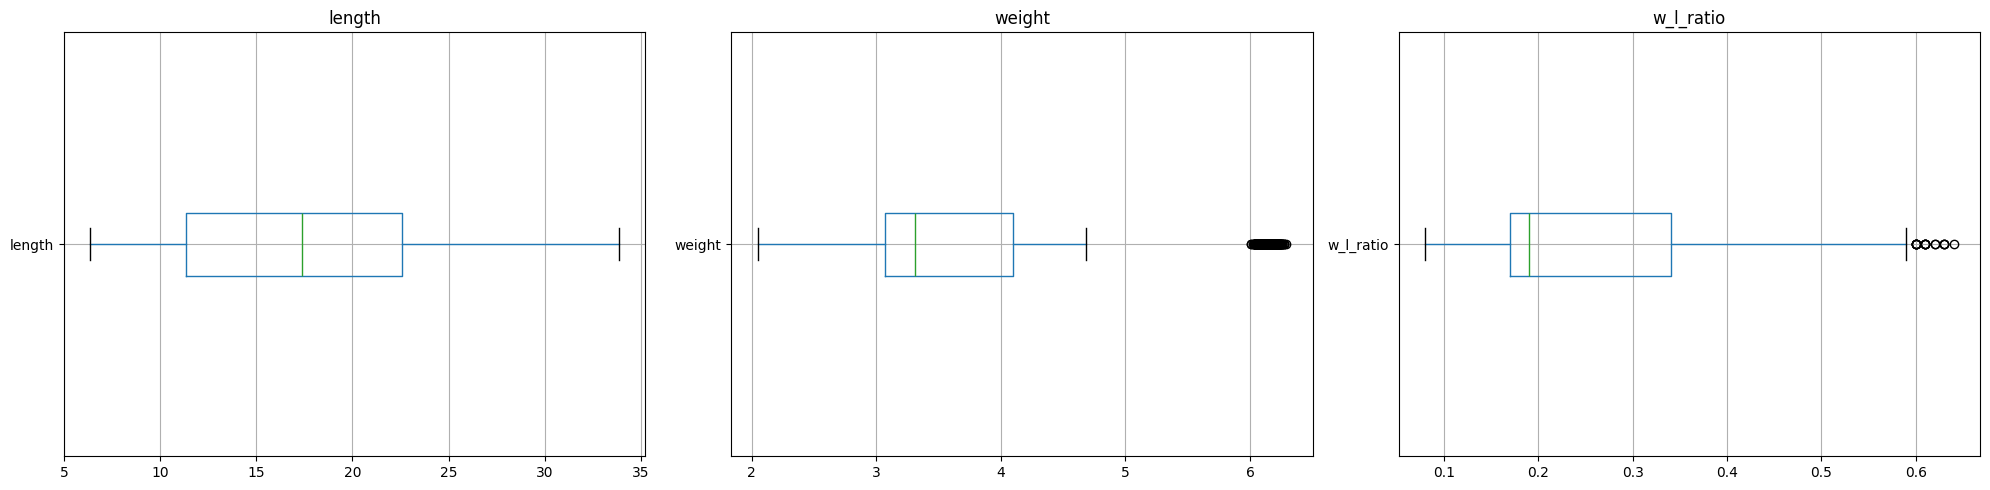

In [6]:
features = ['length', 'weight', 'w_l_ratio']

plt.figure(figsize=(20, 5))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    data.boxplot(column=feature,  vert=False)
    plt.title(feature)

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17844\3101845378.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


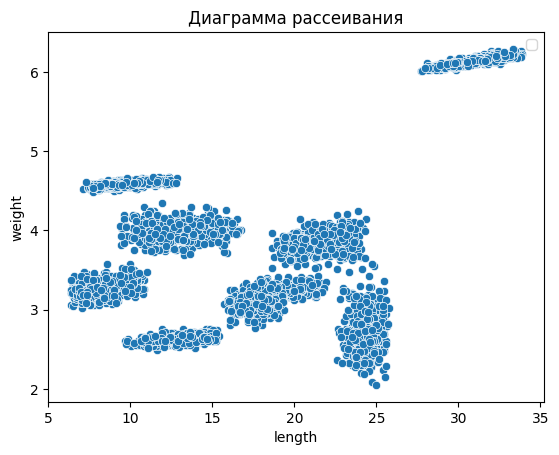

In [7]:
sns.scatterplot(x=data['length'], y=data['weight'])
plt.title('Диаграмма рассеивания')
plt.legend()
plt.show()

In [8]:
Q1 = data.quantile(0.25)

Q3 = data.quantile(0.75)

IQR = Q3 - Q1

lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

mask_out = ((data < lower) | (data > upper)).any(axis = 1)

data[~mask_out]



,length,weight,w_l_ratio
0,10.66,3.45,0.32
1,6.91,3.27,0.47
2,8.38,3.46,0.41
3,7.57,3.36,0.44
4,10.83,3.38,0.31
...,...,...,...
3620,17.98,3.17,0.18
3621,17.23,3.20,0.19
3622,19.01,3.04,0.16
3623,17.97,3.35,0.19


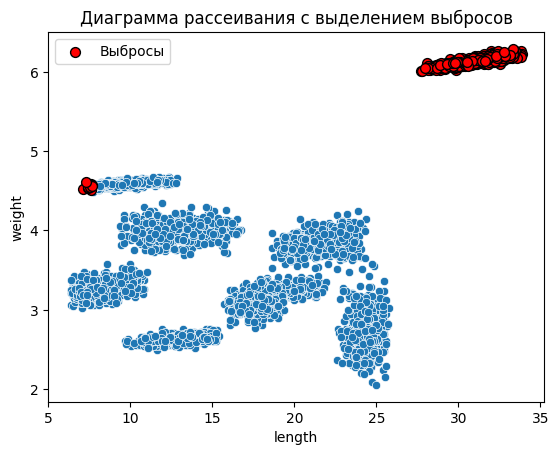

In [9]:
sns.scatterplot(x=data['length'], y=data['weight'])
plt.scatter(data[mask_out]['length'], data[mask_out]['weight'],color='red', edgecolor='black', s=50, label='Выбросы', marker='o')
plt.title('Диаграмма рассеивания с выделением выбросов')
plt.legend()
plt.show()

array([[<Axes: title={'center': 'length'}>,
        <Axes: title={'center': 'weight'}>],
       [<Axes: title={'center': 'w_l_ratio'}>, <Axes: >]], dtype=object)

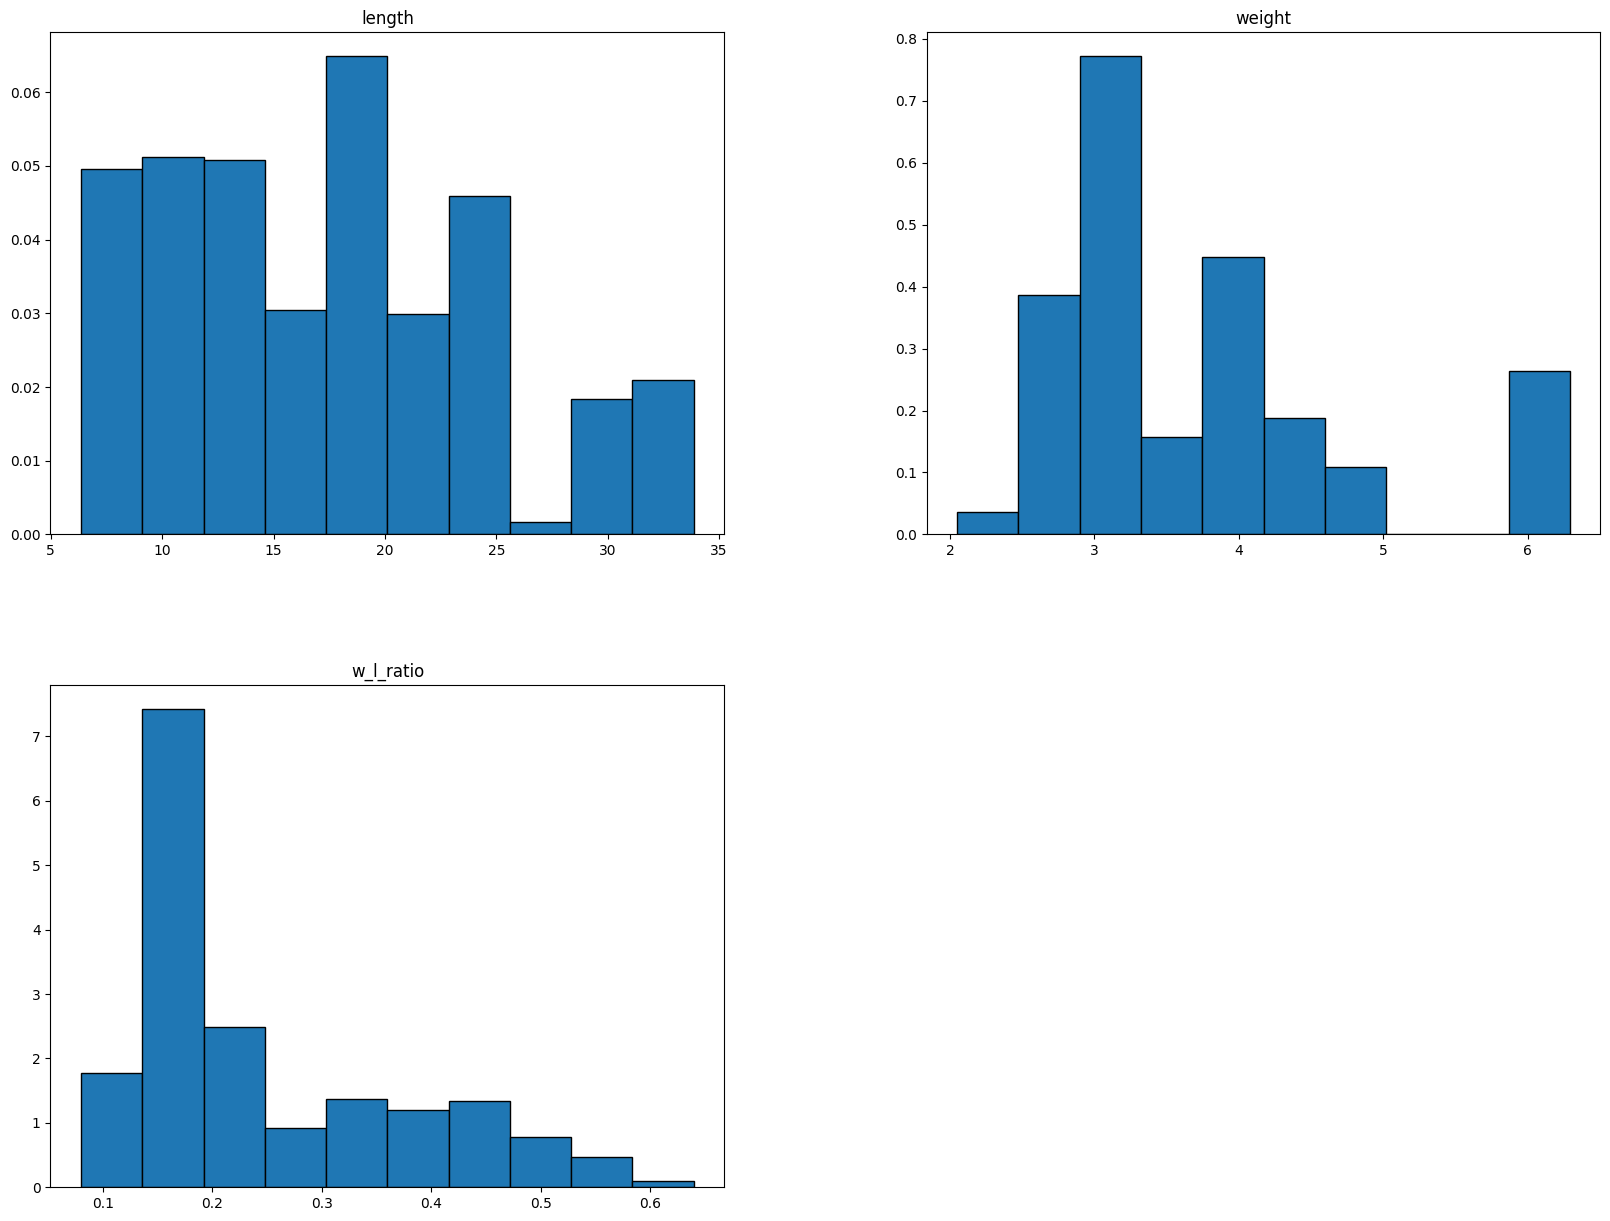

In [10]:
data.hist(figsize=(20,15), grid=False, edgecolor='black', density = True)

In [11]:
data.corr(method='spearman').round(2)

,length,weight,w_l_ratio
length,1.00,0.06,-0.77
weight,0.06,1.00,0.50
w_l_ratio,-0.77,0.50,1.00


<Axes: >

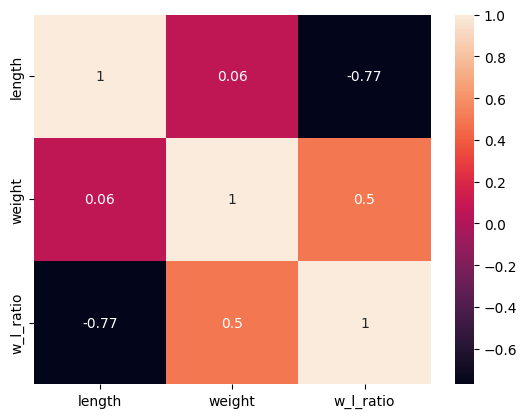

In [12]:
sns.heatmap(data.corr(method='spearman').round(2), annot=True)

In [13]:
data.drop(columns=['w_l_ratio'], inplace=True)

### Нормализация

После очистки данных и анализа статистических характеристик была проведена нормализация признаков с помощью метода MinMaxScaler

Выбор MinMaxScaler обоснован тем, что признаки датасета имеют разные диапазоны, и алгоритмы кластеризации, чувствительные к расстояниям, требуют одинакового масштаба для корректной работы. Кроме того, MinMaxScaler сохраняет относительные различия между значениями и приводит их к диапазону [0, 1], что упрощает интерпретацию и визуализацию данных.

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(data)
scaler_data = pd.DataFrame(X_scaled, columns=data.columns)
scaler_data

,length,weight
0,0.156364,0.330189
1,0.020000,0.287736
2,0.073455,0.332547
3,0.044000,0.308962
4,0.162545,0.313679
...,...,...
4075,0.880000,0.959906
4076,0.847273,0.957547
4077,0.961818,0.990566
4078,0.851636,0.957547


#### Диаграмма рассеивания
Для визуальной оценки структуры данных была построена матрица диаграмм рассеяния

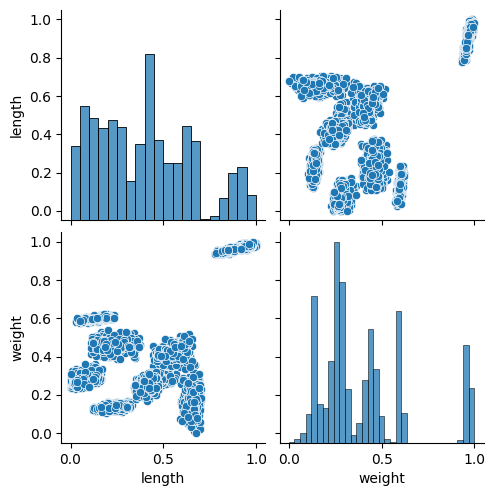

In [15]:
sns.pairplot(scaler_data)



Анализ матрицы диаграмм рассеяния показал наличие нескольких компактных групп объектов, что позволяет предположить 8 кластеров. Кластеры имеют ленточную форму, для такой формы подойдут такие методы как иерархическая кластеризация и DBSCAN.


### DBSCAN

Для метода DBSCAN оптимальные параметры — это eps (максимальное расстояние между соседними точками) и min_samples (минимальное количество точек, формирующих плотный кластер).

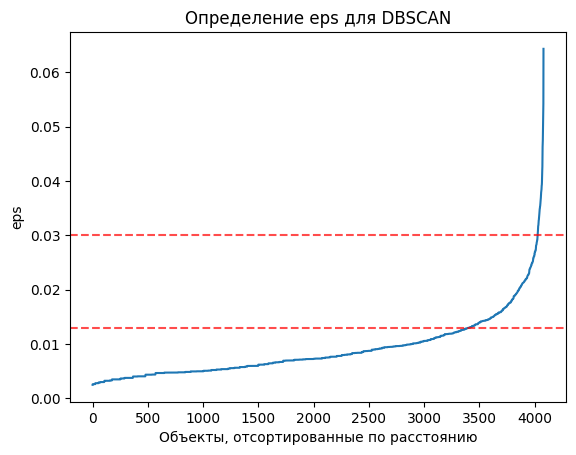

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)  # расстояние до 5-го соседа
plt.plot(distances[:,9])
plt.ylabel("eps")
plt.xlabel("Объекты, отсортированные по расстоянию")
plt.title("Определение eps для DBSCAN")
plt.axhline(y=0.013, color='r', linestyle='--', alpha=0.7, label='eps = 0.01')
plt.axhline(y=0.03, color='r', linestyle='--', alpha=0.7, label='eps = 0.01')
plt.show()


На графике ищут точку «излома», после которой расстояния резко возрастают, и выбирают её значение в качестве eps. Это позволяет алгоритму корректно выделять плотные кластеры и отделять шумовые точки.
Для нашего примера это точка в диапозоне от 0.01 до 0.03

Построим модель с eps = 0.03 и min_samples = 5 

cluster
-1     11
 0    476
 1    408
 2    950
 3    430
 4    475
 5    457
 6    418
 7    455
Name: count, dtype: int64


,length,weight
0,0.066150,0.288028
1,0.653645,0.163990
2,0.429922,0.259494
3,0.561662,0.425378
4,0.117993,0.597984
5,0.239602,0.457315
6,0.244070,0.137453
7,0.898434,0.965364


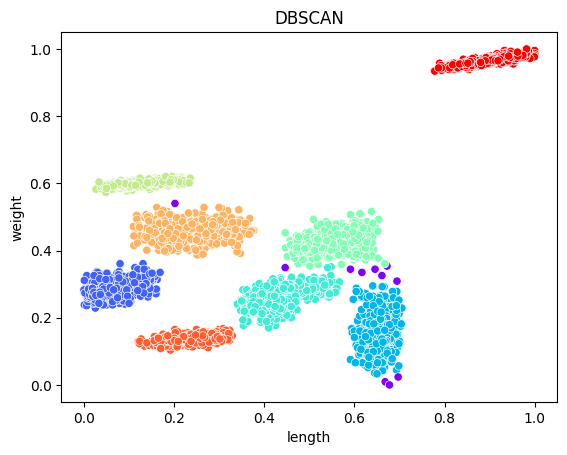

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.027, min_samples=5)

y_dbscan = dbscan.fit_predict(X_scaled)

scaler_data['cluster'] = dbscan.labels_

sns.scatterplot(x = scaler_data['length'], y=scaler_data['weight'], hue=scaler_data['cluster'], palette="rainbow", legend=False)
plt.title('DBSCAN')

print(scaler_data['cluster'].value_counts().sort_index())



scaler_data.drop(columns='cluster', axis=1, inplace=True)
clusters = np.unique(y_dbscan[y_dbscan != -1])
centroids_array = np.array([scaler_data[y_dbscan == k].mean(axis=0) for k in clusters])
centroids_dbscan = pd.DataFrame(centroids_array, columns=scaler_data.columns)
centroids_dbscan

Кластеры с номером -1 DBSCAN определил как шум

### Иерархическая кластеризация

Для выбора оптимального числа кластеров k в иерархической кластеризации можно использовать силуэт-оценку или визуальный анализ дендрограммы.

#### Дендрограмма

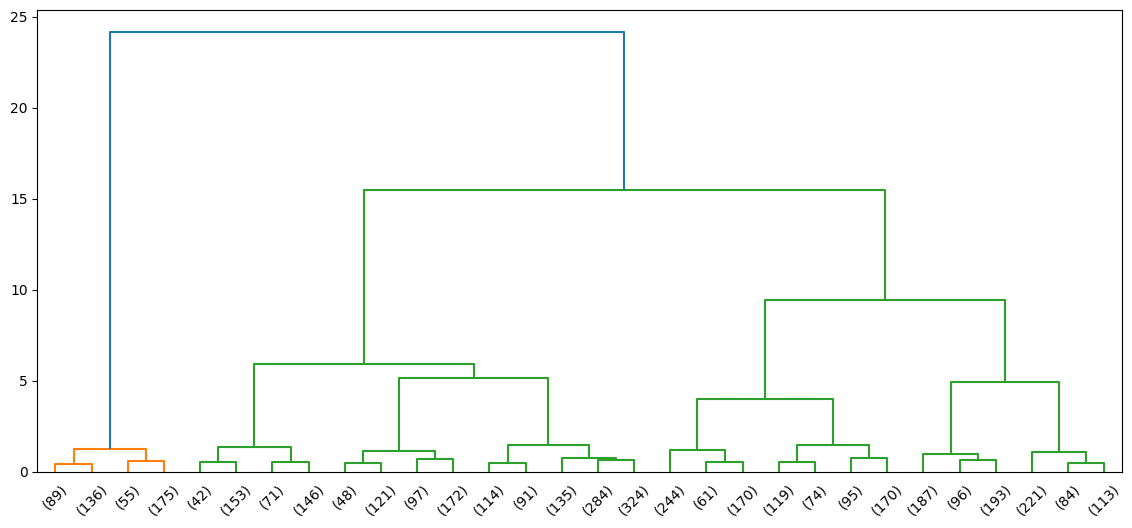

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(14, 6))
dendrogram(
    linkage(X_scaled, method='ward'),
    truncate_mode='lastp',
    p=30,
)
plt.show()

#### Силуэт



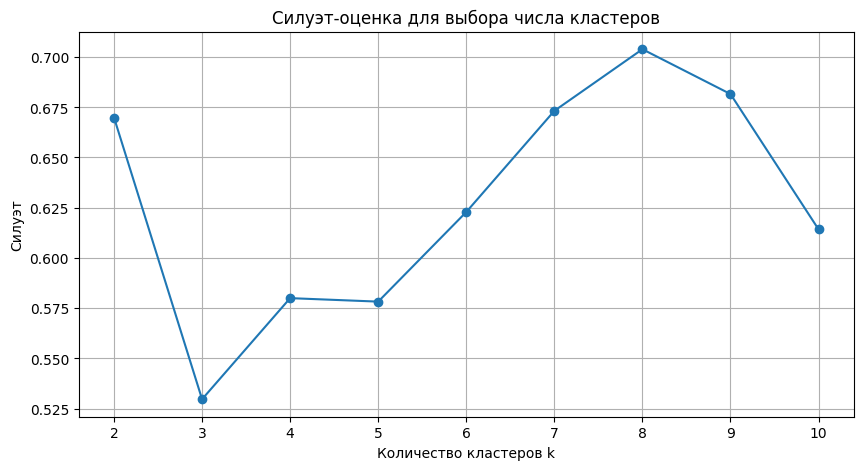

[0.6698879077570591,
 0.529622141684151,
 0.5799476504341926,
 0.5782165963705668,
 0.6228399261643038,
 0.6731976894314314,
 0.7038830400928412,
 0.6815631577865247,
 0.6142016469130853]

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

K_range = range(2, 11) 
silhouette = []

for k in K_range:
    ac = AgglomerativeClustering(n_clusters=k)
    labels = ac.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

plt.figure(figsize=(10,5))
plt.plot(K_range, silhouette, marker='o')
plt.title("Силуэт-оценка для выбора числа кластеров")
plt.xlabel("Количество кластеров k")
plt.ylabel("Силуэт")
plt.grid(True)
plt.show()
silhouette



Значение силуэта достигает максимума 0.7 при k=8, что указывает на наилучшую разделимость кластеров и высокую компактность объектов внутри них. Для меньшего числа кластеров (k=2–7) силуэт ниже, что свидетельствует о слиянии различных групп в слишком крупные кластеры. Для большего числа кластеров (k=9–10) значение силуэта слегка снижается, что отражает избыточное дробление естественных групп. Таким образом, оптимальным числом кластеров для иерархической кластеризации на данном датасете является 8.

Постоим модель с k=8

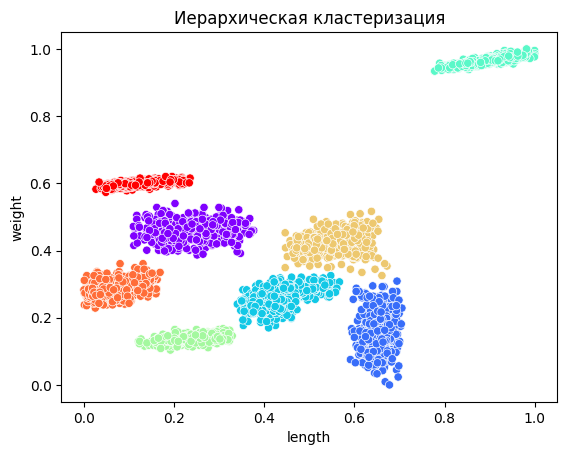

cluster
0    458
1    412
2    948
3    455
4    418
5    438
6    476
7    475
Name: count, dtype: int64


,length,weight
0,0.239520,0.457496
1,0.653944,0.163228
2,0.429680,0.259302
3,0.898434,0.965364
4,0.244070,0.137453
5,0.562186,0.423893
6,0.066150,0.288028
7,0.117993,0.597984


In [20]:

model_ac = AgglomerativeClustering(n_clusters=8,)

y_ac = model_ac.fit_predict(X_scaled)

scaler_data['cluster'] = model_ac.labels_

sns.scatterplot(x = scaler_data['length'], 
                y = scaler_data['weight'], 
                hue = scaler_data['cluster'], 
                palette="rainbow",
                legend=False
                )
plt.title('Иерархическая кластеризация')
plt.show()
print(scaler_data['cluster'].value_counts().sort_index())
scaler_data.drop(columns='cluster', axis=1, inplace=True)
centroids_ac = pd.DataFrame(scaler_data.groupby(y_ac).mean().values, columns=data.columns)
centroids_ac

In [21]:
from scipy.spatial.distance import cdist, pdist

def distances(centroids):

    dist_matrix = cdist(centroids.values, centroids.values, metric='euclidean')
    pairwise_distances = pdist(centroids.values, metric='euclidean')
    mean_distance = pairwise_distances.mean()
    distances = pd.DataFrame(dist_matrix, 
                            columns=[f'Cluster{i}' for i in range(len(centroids))],
                            index=[f'Cluster{i}' for i in range(len(centroids))])
    
    return  mean_distance

mean_distance_ac = distances(centroids_ac)

mean_distance_kmeans = distances(centroids_dbscan)

print("Среднее межкластерное расстояние Agglomerative:", mean_distance_ac)

print("Среднее межкластерное расстояние KMeans:", mean_distance_kmeans)


Среднее межкластерное расстояние Agglomerative: 0.49737536453611464
Среднее межкластерное расстояние KMeans: 0.4972132523937041


In [22]:
def intra_distances(centroids, y_pred):
    intra_distances = []

    for i in range(len(centroids)):
        cluster_points = X_scaled[y_pred == i]
        centroid = centroids.iloc[i].to_numpy().reshape(1, -1)  
        distances = cdist(cluster_points, centroid, metric='euclidean')
        mean_distance = distances.mean()
        intra_distances.append(mean_distance)
    return np.mean(intra_distances)

intra_dbscan = intra_distances(centroids_dbscan, y_dbscan)

intra_ac = intra_distances(centroids_ac, y_ac)

print("Средние внутрикластерные расстояния AC:\n", intra_dbscan)
print("Средние внутрикластерные расстояния Kmens:\n", intra_ac)

Средние внутрикластерные расстояния AC:
 0.045730866324857594
Средние внутрикластерные расстояния Kmens:
 0.04596021063916851


### Расчет метрик качества

#### Внутренние метрики

Внутренние метрики отображают качество кластеризации только по информации в данных.

##### Компактность кластеров (Cluster Cohesion)
Идея данного метода в том, что чем ближе друг к другу находятся объекты внутри кластеров, тем лучше разделение.

Таким образом, необходимо минимизировать внутриклассовое расстояние, например, сумму квадратов отклонений:

In [23]:
mask = y_dbscan != -1
def cluster_cohesion(X, labels):
    
    X = np.array(X)
    labels = np.array(labels)

    clusters = np.unique(labels)

    WSS = 0.0
    per_cluster_wss = {}
    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)
        wss = np.sum(np.linalg.norm(points - mean_cluster, axis=1)**2)
        per_cluster_wss[cluster] = float(wss)
        WSS += wss
    return float(WSS)



Посчитаем данную метрику для наших методов

In [24]:
wss_dbscan = cluster_cohesion(X_scaled[mask], y_dbscan[mask])

wss_ac =cluster_cohesion(X_scaled, y_ac)

print('Kомпактность kmens:',wss_dbscan)

print('Kомпактность ac:',wss_ac)

Kомпактность kmens: 11.238578146960124
Kомпактность ac: 11.399002694564231


##### Отделимость кластеров (Cluster Separation)

В данном случае идея противоположная — чем дальше друг от друга находятся объекты разных кластеров, тем лучше.

Поэтому здесь стоит задача максимизации суммы квадратов отклонений:

In [25]:
def cluster_separation(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    global_mean = X.mean(axis=0)

    clusters = np.unique(labels)

    BSS = 0.0
    per_cluster_bss = {}

    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)

        bss_j = np.linalg.norm(mean_cluster - global_mean)**2
        per_cluster_bss[cluster] = float(bss_j)

        BSS += bss_j
    print(BSS, n)
    BSS_total = n * BSS

    return float(BSS_total)

Посчитаем данную метрику для наших методов

In [26]:
bss_dbscan = cluster_separation(X_scaled, y_dbscan)

bss_ac =cluster_separation(X_scaled, y_ac)

print(bss_dbscan)

print(bss_ac)

1.1007984413134337 4080
1.101487248016886 4080
4491.25764055881
4494.067971908895


##### Силуэт (Silhouette)

Значение силуэта показывает, насколько объект похож на свой кластер по сравнению с другими кластерами.

Чем ближе данная оценка к 1, тем лучше.

Посчитаем данную метрику для наших методов

In [27]:
from sklearn.metrics import silhouette_score

dbscan_silhouette_score = silhouette_score(X_scaled, y_dbscan)

ac_silhouette_score = silhouette_score(X_scaled, y_ac)

print('Силуэт dbscan:',dbscan_silhouette_score)

print('Силуэт ac:',ac_silhouette_score)

Силуэт dbscan: 0.6975956068398304
Силуэт ac: 0.7038830400928412


In [28]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch_dbscan = calinski_harabasz_score(X_scaled, y_dbscan)
db_dbscan = davies_bouldin_score(X_scaled, y_dbscan)

# Метрики для иерархической кластеризации
ch_ac = calinski_harabasz_score(X_scaled, y_ac)
db_ac = davies_bouldin_score(X_scaled, y_ac)

# Вывод результатов
print("Calinski-Harabasz DBSCAN:", ch_dbscan)
print("Davies-Bouldin DBSCAN:", db_dbscan)
print("Calinski-Harabasz Agglomerative:", ch_ac)
print("Davies-Bouldin Agglomerative:", db_ac)


Calinski-Harabasz DBSCAN: 21916.102350409165
Davies-Bouldin DBSCAN: 1.0242843556970633
Calinski-Harabasz Agglomerative: 25883.669050040528
Davies-Bouldin Agglomerative: 0.4041802395871224


In [29]:
metric = {
    "Внутренние метрики": [
        'Среднее межкластерное расстояние',
        'Средние внутрикластерные расстояния',
        'Компактность',
        'Силуэт',
        'Calinski-Harabasz',
        'Davies–Bouldin',
    ],
    "Иерархическая кластеризация": [
        mean_distance_ac,
        intra_ac,
        wss_ac,
        ac_silhouette_score,
        ch_ac,
        db_ac
    ],
    "DBSCAN": [
        mean_distance_kmeans,
        intra_dbscan,
        wss_dbscan,
        dbscan_silhouette_score,
        ch_dbscan,
        db_dbscan
    ]
}

metric = pd.DataFrame(metric)

metric

,Внутренние метрики,Иерархическая кластеризация,DBSCAN
0,Среднее межкластерное расстояние,0.497375,0.497213
1,Средние внутрикластерные расстояния,0.045960,0.045731
2,Компактность,11.399003,11.238578
3,Силуэт,0.703883,0.697596
4,Calinski-Harabasz,25883.669050,21916.102350
5,Davies–Bouldin,0.404180,1.024284


#### Внешние метрики

Внешние меры основаны на сравнении результата кластеризации с априори известным разделением на классы.

У нас есть заранее известные классы в y_true (9 кластеров)

##### Индекс Rand

Индекс Rand оценивает, насколько много из тех пар элементов, которые находились в одном классе, и тех пар элементов, которые находились в разных классах, сохранили это состояние после кластеризации алгоритмом.

Имеет область определения от 0 до 1, где 1 — полное совпадение кластеров с заданными классами, а 0 — отсутствие совпадений.

Посчитаем данную метрику для наших моделей

In [30]:
from sklearn.metrics import rand_score, pair_confusion_matrix

rand_ac = rand_score(y_true, y_ac)

rand_dbscan = rand_score(y_true, y_dbscan)

print("Rand Index Agglomerative Clustering:", rand_ac)
print("Rand Index DBSCAN:", rand_dbscan)

print("\nPair Confusion Matrix DBSCAN:")
print(pair_confusion_matrix(y_true, y_dbscan))

print("\nPair Confusion Matrix Agglomerative Clustering:")
print(pair_confusion_matrix(y_true, y_ac))

Rand Index Agglomerative Clustering: 0.9726983978195348
Rand Index DBSCAN: 0.9720111138350903

Pair Confusion Matrix DBSCAN:
[[14337814   453998]
 [   11802  1838706]]

Pair Confusion Matrix Agglomerative Clustering:
[[14339922   451890]
 [    2472  1848036]]


#### Индекс Adjusted Rand

В отличие от обычного индекса Rand, индекс Adjusted Rand может принимать отрицательные значения

Посчитаем данную метрику для наших моделей

In [31]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_ac = adjusted_rand_score(y_true, y_ac)

adjusted_rand_dbscan = adjusted_rand_score(y_true, y_dbscan)

print("Adjusted Rand Index Agglomerative Clustering:", adjusted_rand_ac)
print("Adjusted Rand Index DBSCAN:", adjusted_rand_dbscan)

print(set(y_ac))
print(set(y_dbscan))
print(set(y_true))


Adjusted Rand Index Agglomerative Clustering: 0.8751397055870552
Adjusted Rand Index DBSCAN: 0.8717986522383063
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)}
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}


#### Индекс Жаккара (Jaccard Index)

Индекс Жаккара похож на Индекс Rand, только не учитывает пары элементов находящиеся в разные классах и разных кластерах (TN)

Имеет область определения от 0 до 1, где 1 — полное совпадение кластеров с заданными классами, а 0 — отсутствие совпадений.

Посчитаем данную метрику для наших моделей

In [32]:
def J(y_true, y_pred):
    (tn, fp), (fn, tp) = pair_confusion_matrix(y_true, y_pred)
    return tp / (tp + fn + fp)
jaccard_rand_ac = J(y_true, y_ac)
jaccard_rand_dbscan = J(y_true, y_dbscan)

print("jaccard Agglomerative Clustering:", jaccard_rand_ac)
print("jaccard dbscan:", jaccard_rand_dbscan)

jaccard Agglomerative Clustering: 0.8026570558174564
jaccard dbscan: 0.797874251574958


In [33]:
from sklearn.metrics import jaccard_score

jaccard_rand_ac = jaccard_score(y_true, y_ac, average='macro')

jaccard_rand_dbscan = jaccard_score(y_true, y_dbscan, average='macro')

print("jaccard Agglomerative Clustering:", jaccard_rand_ac)
print("jaccard DBSCAN:", jaccard_rand_dbscan)

jaccard Agglomerative Clustering: 0.16516021893481098
jaccard DBSCAN: 0.6457525657082754


#### Индекс Фоулкса – Мэллова (Fowlkes-Mallows Index)

Индекс Фоулкса – Мэллова используется для определения сходства между двумя кластерами.

Более высокое значение индекса означает большее сходство между кластерами. Этот индекс также хорошо работает на зашумленных данных.

Посчитаем данную метрику для наших моделей

In [34]:
from sklearn.metrics import fowlkes_mallows_score

fm_ac = fowlkes_mallows_score(y_true, y_ac)
fm_dbscan = fowlkes_mallows_score(y_true, y_dbscan)

print("Fowlkes–Mallows Agglomerative Clustering:", fm_ac)
print("Fowlkes–Mallows DBSCAN:", fm_dbscan)

Fowlkes–Mallows Agglomerative Clustering: 0.8957937173382421
Fowlkes–Mallows DBSCAN: 0.8926738555588126


### Сравнительный анализ

In [35]:
metric = {
    "Внешние метрики": [
        'Индекс Rand',
        'ARI',
        'Индекс Жаккара',
        'Индекс Фоулкса – Мэллова'

    ],
    "Иерархическая кластеризация": [
        rand_ac,
        adjusted_rand_ac,
        jaccard_rand_ac,
        fm_ac

    ],
    "DBSCAN": [
        rand_dbscan,
        adjusted_rand_dbscan,
        jaccard_rand_dbscan,
        fm_dbscan

    ]
}

metric = pd.DataFrame(metric)

metric

,Внешние метрики,Иерархическая кластеризация,DBSCAN
0,Индекс Rand,0.972698,0.972011
1,ARI,0.875140,0.871799
2,Индекс Жаккара,0.165160,0.645753
3,Индекс Фоулкса – Мэллова,0.895794,0.892674


Оба алгоритма кластеризации — DBSCAN и Agglomerative Clustering — демонстрируют высокое качество разделения данных. По компактности кластеров WSS у DBSCAN составляет 24.45 против 24.81 у Agglomerative, что говорит о чуть более плотных кластерах у DBSCAN. Межклассовой разброс BSS чуть выше у Agglomerative (6035.61 против 6032.28), значит центры кластеров у него чуть дальше друг от друга. Silhouette Score близок: 0.6604 для Agglomerative и 0.6589 для DBSCAN, что подтверждает схожую структуру кластеров.

Метрики совпадения с эталонными метками также высоки: Rand Index 0.9727 (Agglomerative) и 0.9722 (DBSCAN), Adjusted Rand Index 0.8751 и 0.8727 соответственно, Fowlkes–Mallows Score 0.8958 и 0.8933. При этом Jaccard Index значительно выше у DBSCAN — 0.646 против 0.110 у Agglomerative, что указывает на более точное выделение пар объектов одного класса.

Таким образом, DBSCAN чуть выигрывает по точности соответствия меткам, а Agglomerative — по разнесённости центров кластеров, при этом оба метода показывают очень хорошие результаты.

In [36]:
print('Центры dbscan\n',centroids_dbscan)

print('Центры ac\n',centroids_ac)

Центры dbscan
      length    weight
0  0.066150  0.288028
1  0.653645  0.163990
2  0.429922  0.259494
3  0.561662  0.425378
4  0.117993  0.597984
5  0.239602  0.457315
6  0.244070  0.137453
7  0.898434  0.965364
Центры ac
      length    weight
0  0.239520  0.457496
1  0.653944  0.163228
2  0.429680  0.259302
3  0.898434  0.965364
4  0.244070  0.137453
5  0.562186  0.423893
6  0.066150  0.288028
7  0.117993  0.597984


C:\Users\Admin\AppData\Local\Temp\ipykernel_17844\66088155.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='length', data=data_with_clusters, palette="rainbow", ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_17844\66088155.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='weight', data=data_with_clusters, palette="rainbow", ax=axes[1])


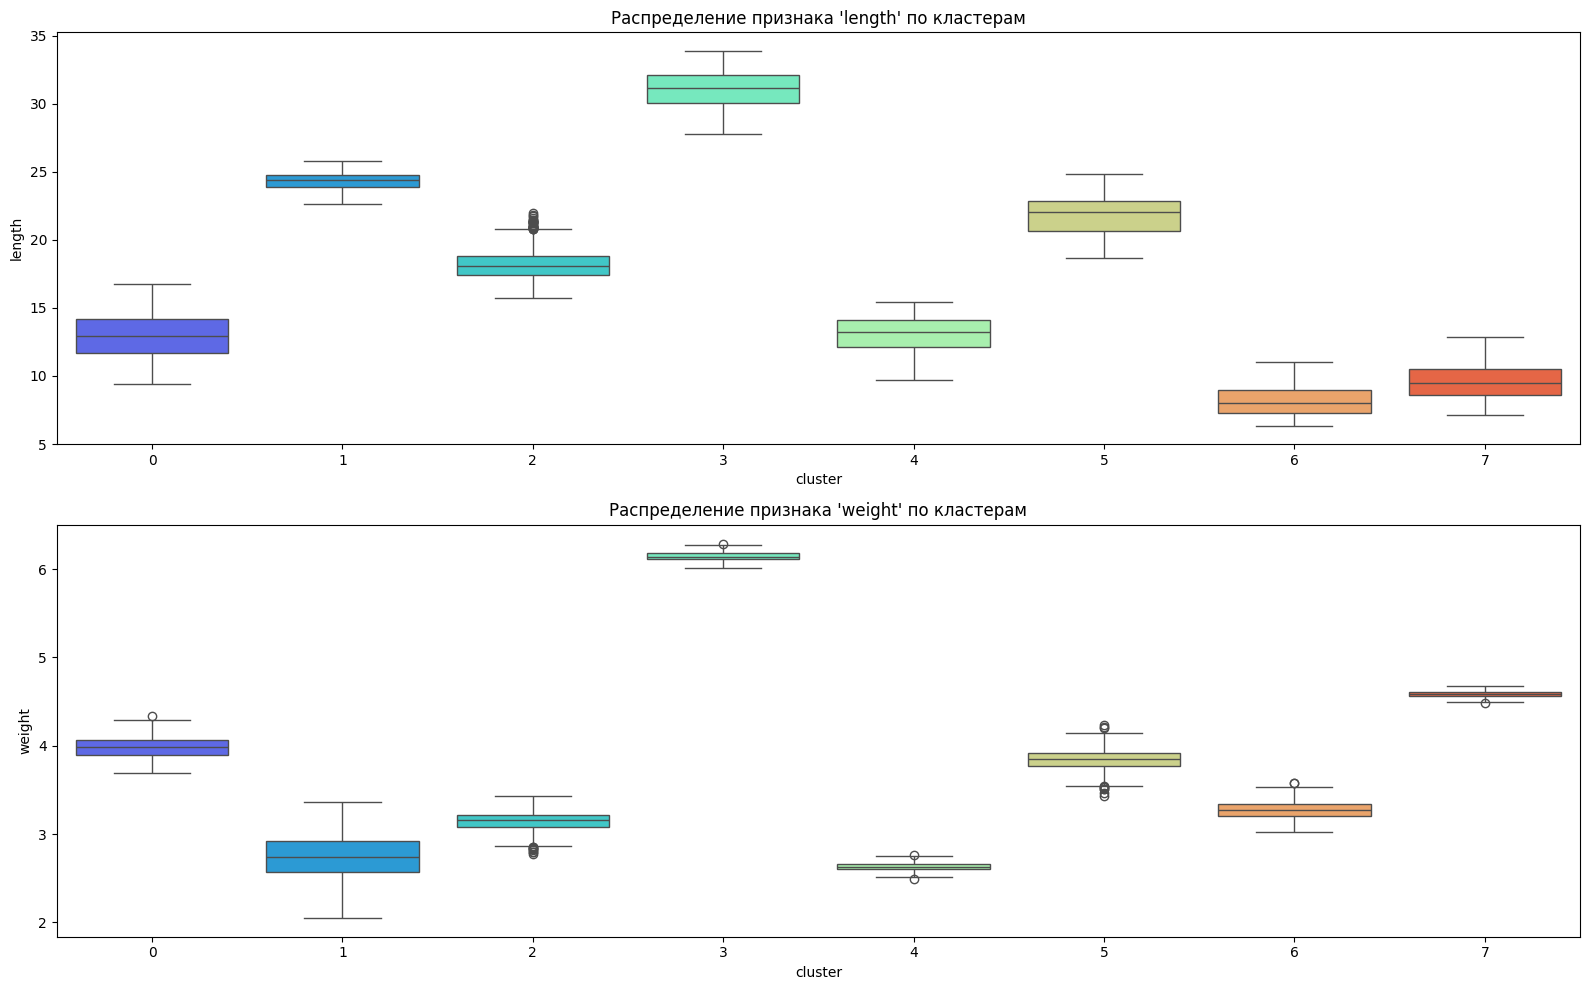

In [37]:
data_with_clusters = data.copy()
data_with_clusters['cluster'] = y_ac  # или y_dbscan для DBSCAN

# Создаем фигуру с 2 подграфиками (по количеству признаков)
fig, axes = plt.subplots(2, 1, figsize=(16,10))

# Boxplot для признака 'length'
sns.boxplot(x='cluster', y='length', data=data_with_clusters, palette="rainbow", ax=axes[0])
axes[0].set_title("Распределение признака 'length' по кластерам")

# Boxplot для признака 'weight'
sns.boxplot(x='cluster', y='weight', data=data_with_clusters, palette="rainbow", ax=axes[1])
axes[1].set_title("Распределение признака 'weight' по кластерам")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17844\4223115749.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='length', data=filtered_data, palette="rainbow", ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_17844\4223115749.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='weight', data=filtered_data, palette="rainbow", ax=axes[1])


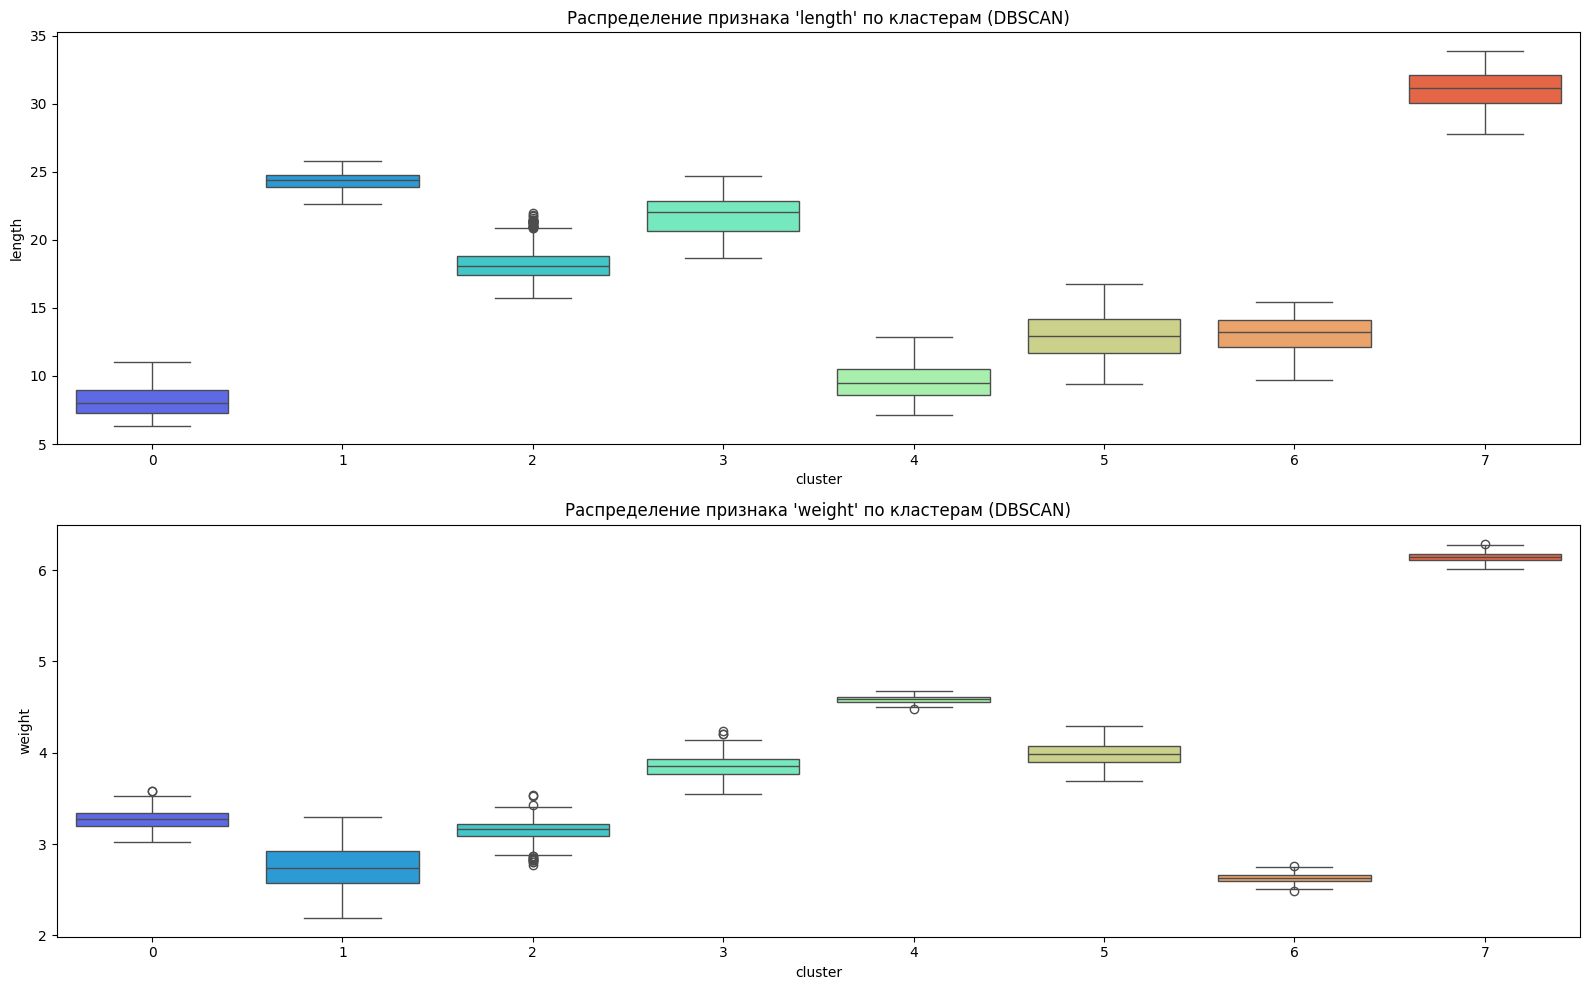

In [38]:
data_with_clusters = data.copy()
data_with_clusters['cluster'] = y_dbscan

# Фильтруем шум (-1), если хотим строить график только по кластерам
filtered_data = data_with_clusters[data_with_clusters['cluster'] != -1]

# Фигура с двумя подграфиками
fig, axes = plt.subplots(2, 1, figsize=(16,10))

# Boxplot для признака 'length'
sns.boxplot(x='cluster', y='length', data=filtered_data, palette="rainbow", ax=axes[0])
axes[0].set_title("Распределение признака 'length' по кластерам (DBSCAN)")

# Boxplot для признака 'weight'
sns.boxplot(x='cluster', y='weight', data=filtered_data, palette="rainbow", ax=axes[1])
axes[1].set_title("Распределение признака 'weight' по кластерам (DBSCAN)")

plt.tight_layout()
plt.show()

In [39]:
data_ac = data.copy()
data_ac['cluster'] = y_ac

summary_ac = data_ac.groupby('cluster').agg(['mean', 'min', 'max'])
print("Статистика признаков по кластерам (Agglomerative):")
print(summary_ac)

# Для DBSCAN (исключаем шум -1)
data_dbscan = data.copy()
data_dbscan['cluster'] = y_dbscan

summary_dbscan = data_dbscan[data_dbscan['cluster'] != -1].groupby('cluster').agg(['mean', 'min', 'max'])
print("\nСтатистика признаков по кластерам (DBSCAN):")
print(summary_dbscan)

Статистика признаков по кластерам (Agglomerative):
            length                  weight            
              mean    min    max      mean   min   max
cluster                                               
0        12.946812   9.38  16.72  3.989782  3.69  4.34
1        24.343471  22.62  25.76  2.742087  2.05  3.36
2        18.176192  15.72  21.95  3.149441  2.77  3.43
3        31.066923  27.75  33.86  6.143143  6.01  6.29
4        13.071938   9.69  15.41  2.632799  2.49  2.76
5        21.820114  18.64  24.85  3.847306  3.43  4.24
6         8.179139   6.36  11.01  3.271239  3.02  3.58
7         9.604800   7.10  12.84  4.585453  4.48  4.68

Статистика признаков по кластерам (DBSCAN):
            length                  weight            
              mean    min    max      mean   min   max
cluster                                               
0         8.179139   6.36  11.01  3.271239  3.02  3.58
1        24.335245  22.62  25.76  2.745319  2.19  3.30
2        18.182842  15.7

In [40]:
from sklearn.feature_selection import f_classif

# Для иерархической кластеризации (AC)
mask_ac = np.ones_like(y_ac, dtype=bool)  # все точки включаем
X_ac = X_scaled[mask_ac]
y_ac_labels = y_ac[mask_ac]

f_stat_ac, p_val_ac = f_classif(X_ac, y_ac_labels)

# ------------------------
# Для DBSCAN (исключаем шум -1)
mask_db = y_dbscan != -1
X_db = X_scaled[mask_db]
y_db_labels = y_dbscan[mask_db]

f_stat_db, p_val_db = f_classif(X_db, y_db_labels)

# ------------------------
# Объединяем результаты в один DataFrame
feature_names = data.columns  # названия признаков

anova_comparison = pd.DataFrame({
    'Признак': feature_names,
    'F-статистика AC': f_stat_ac,
    'p-value AC': p_val_ac,
    'F-статистика DBSCAN': f_stat_db,
    'p-value DBSCAN': p_val_db
})

print(anova_comparison)

  Признак  F-статистика AC  p-value AC  F-статистика DBSCAN  p-value DBSCAN
0  length     18616.678890         0.0         18581.296988             0.0
1  weight     45112.839163         0.0         46937.857193             0.0


### Влияние параметров на качество медотода иерархической кластеризации

Исследуем влияние количества кластеров и связи:

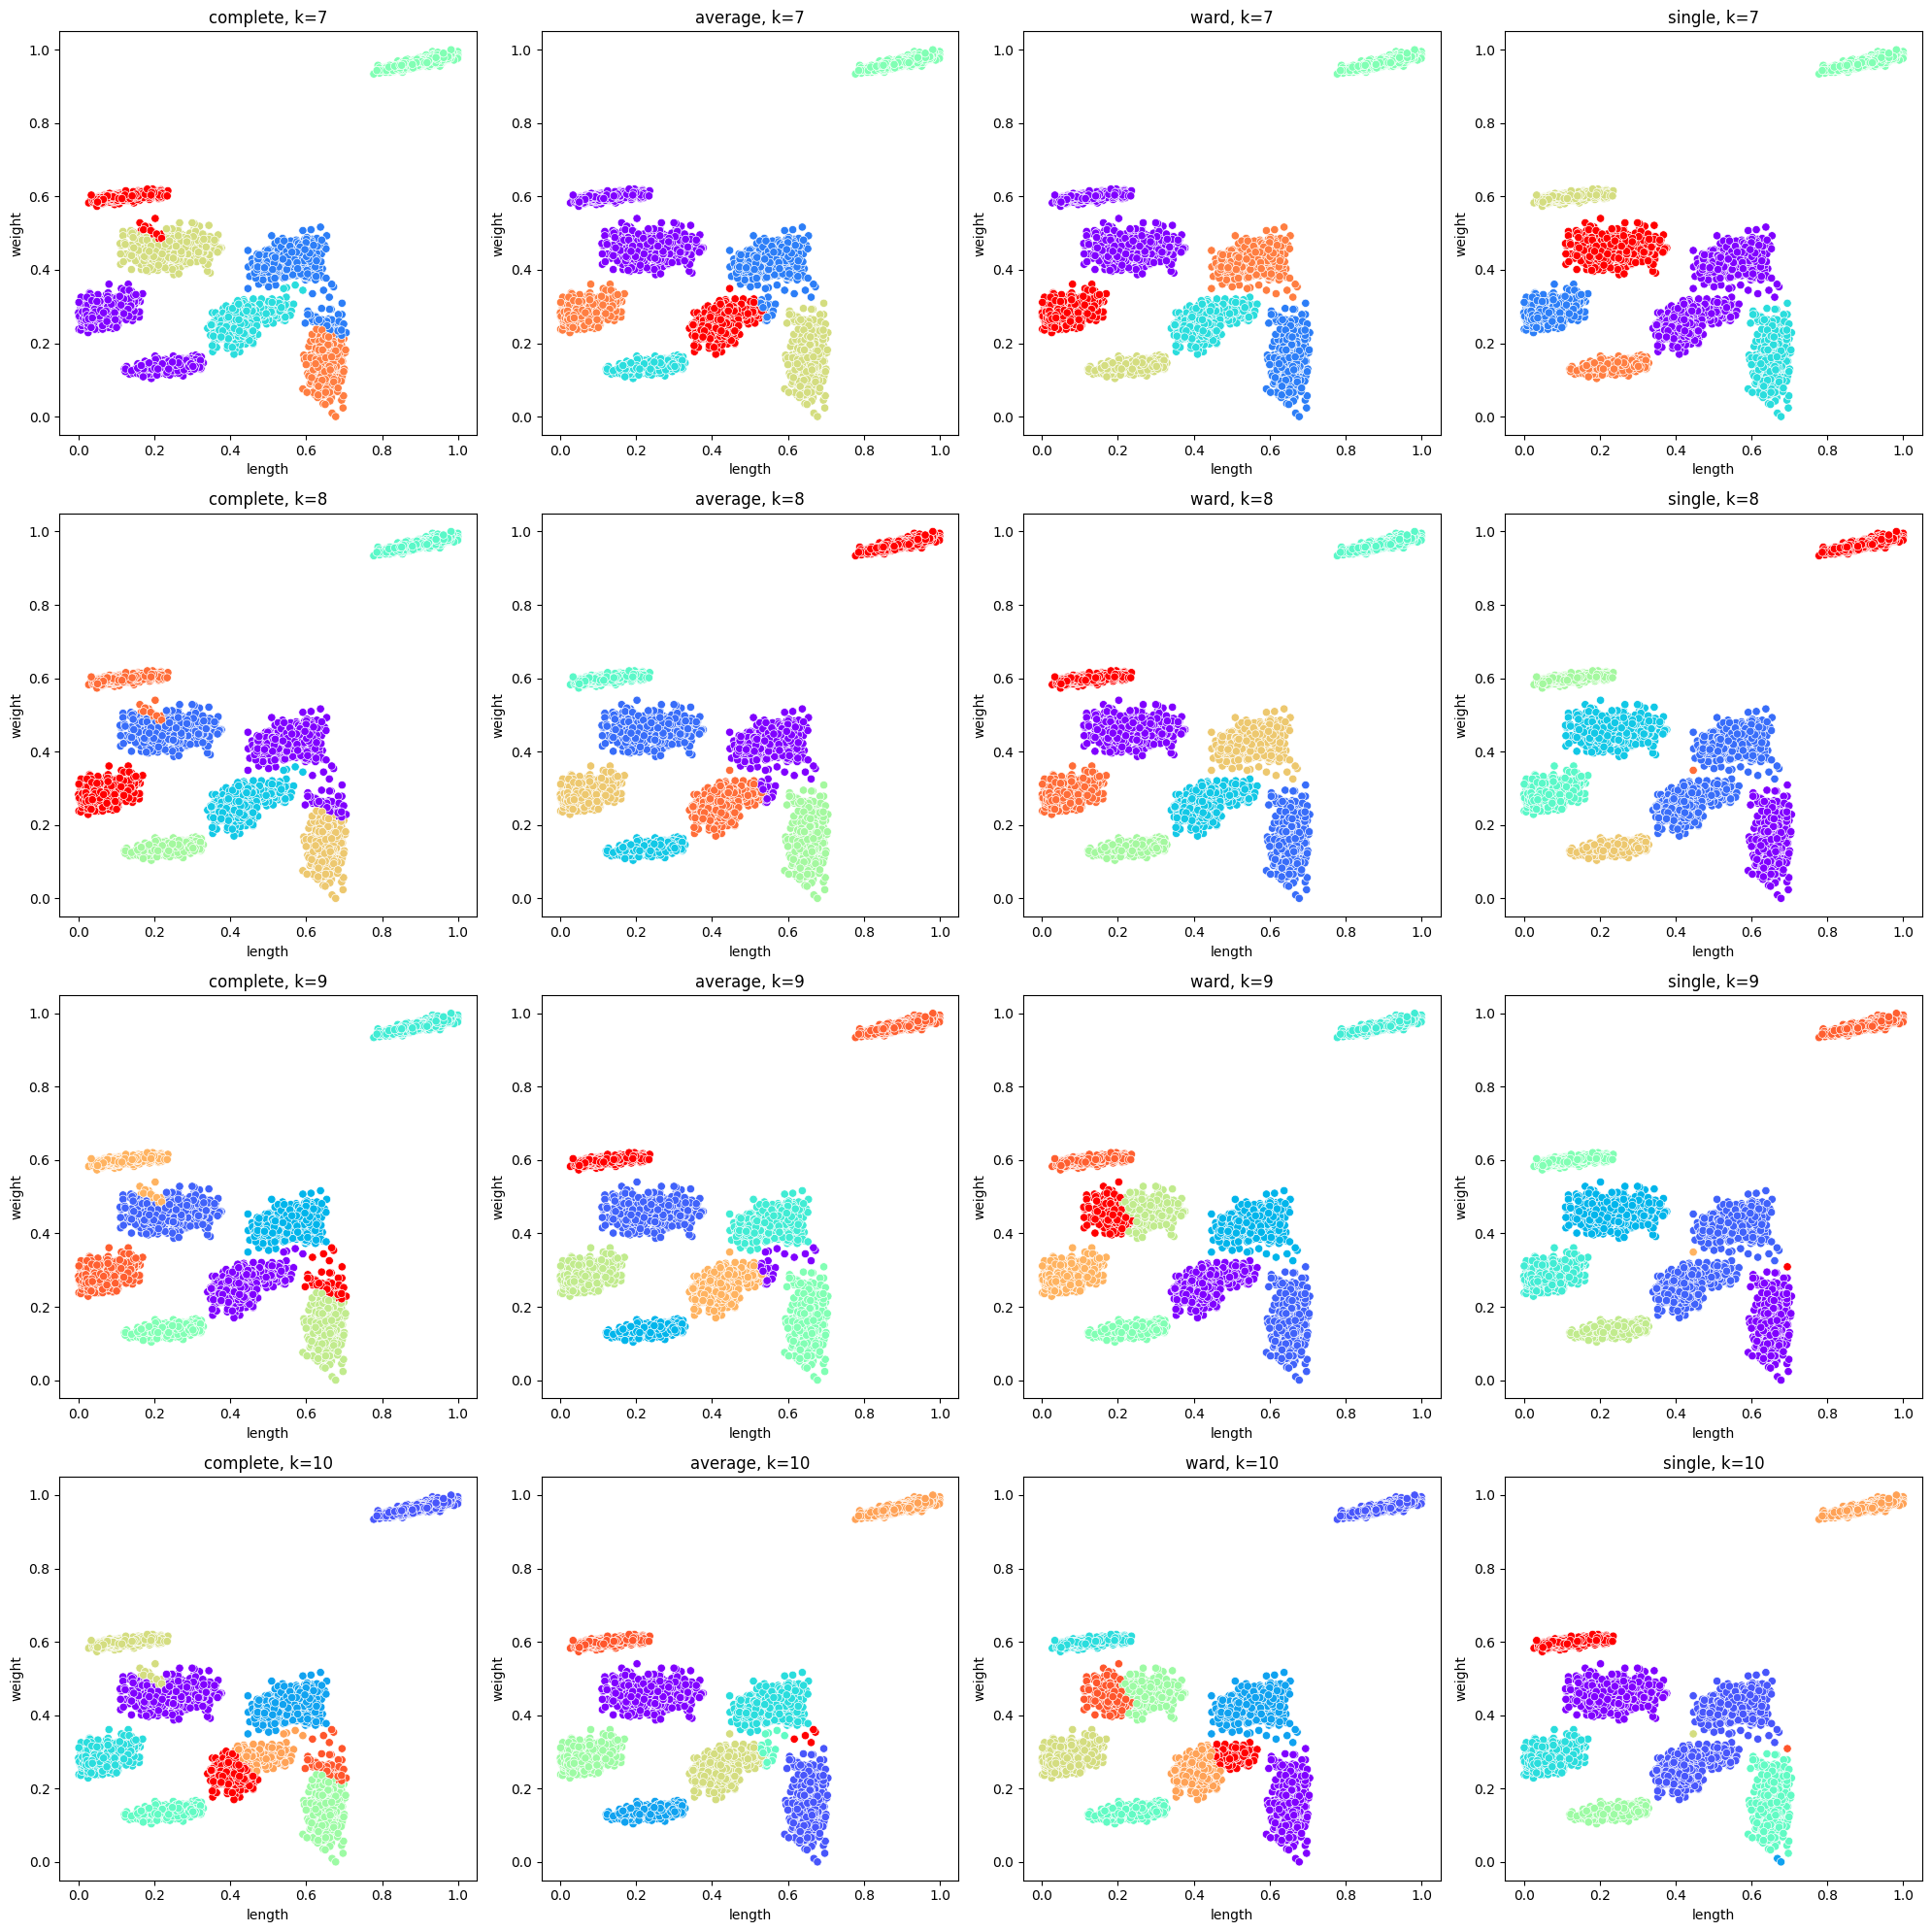

,n_clusters,linkage,Ср межк расстояние,Ср внутрик расстояния,Kомпактность,Силуэт,Calinski-Harabasz,Davies-Bouldin,Rand,ARI,Jaccard Index,Fowlkes-Mallows Index
0,7,complete,0.506875,0.060159,24.953690,0.609231,13429.109621,0.523025,0.941077,0.752274,0.646110,0.799360
1,7,average,0.515265,0.053617,19.470485,0.671993,17402.135677,0.418758,0.945371,0.770537,0.667897,0.815653
2,7,ward,0.515751,0.053378,19.444852,0.673198,17425.970856,0.412583,0.946554,0.776366,0.675082,0.821456
3,7,single,0.527727,0.053677,24.774860,0.629323,13530.943681,0.499834,0.922799,0.700142,0.589890,0.767833
4,8,complete,0.498149,0.047548,12.862374,0.683182,22872.663731,0.440699,0.964988,0.840320,0.754458,0.865399
5,8,average,0.496989,0.046170,11.424636,0.702722,25824.289461,0.409541,0.971516,0.869183,0.794111,0.890073
6,8,ward,0.497375,0.045960,11.399003,0.703883,25883.669050,0.404180,0.972698,0.875140,0.802657,0.895794
7,8,single,0.481942,0.046972,24.772809,0.436359,11596.112495,0.905556,0.922861,0.700233,0.589972,0.767812
8,9,complete,0.480945,0.044505,11.145070,0.661919,23170.139880,0.488290,0.967618,0.850811,0.768461,0.873527
9,9,average,0.467828,0.045338,11.055790,0.645697,23361.356570,0.525684,0.972441,0.872733,0.799010,0.892614


In [41]:
linkages = {'ward', 'complete', 'average', 'single'}

result_ac = []
fig, axes = plt.subplots(4, 4, figsize=(20, 20))   # 4×4 полотно
axes = axes.flatten()
plot_index = 0

for n in range(7,11):
    for link in linkages:

        model_AC = AgglomerativeClustering(n_clusters=n, linkage=link)

        y_AC = model_AC.fit_predict(X_scaled)
        scaler_data['cluster'] = y_AC
        centroids_AC = scaler_data.groupby('cluster').mean()
        ax = axes[plot_index]
        sns.scatterplot(x = scaler_data['length'], 
                        y = scaler_data['weight'], 
                        hue = scaler_data['cluster'], 
                        palette="rainbow",
                        legend=False,
                        ax=ax
                        )
        
        # ax.scatter(
        #     centroids_AC['length'],
        #     centroids_AC['weight'],
        #     s=100,
        #     c='black',
        #     marker='X',
        #     edgecolor='white',
        #     linewidth=2
        # )
        
        ax.set_title(f'{link}, k={n}', fontsize=12)
        plot_index += 1

        scaler_data.drop(columns=['cluster'], inplace=True)

        result_ac.append({
            'n_clusters': n,
            'linkage': link,
            'Ср межк расстояние': distances(centroids_AC),
            'Ср внутрик расстояния': intra_distances(centroids_AC, y_AC),
            'Kомпактность': cluster_cohesion(X_scaled, y_AC),
            'Силуэт': silhouette_score(X_scaled, y_AC),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled, y_AC),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, y_AC),
            'Rand': rand_score(y_true, y_AC),
            'ARI': adjusted_rand_score(y_true, y_AC),
            'Jaccard Index' : J(y_true, y_AC),
            'Fowlkes-Mallows Index': fowlkes_mallows_score(y_true, y_AC)
            })
plt.tight_layout()
plt.show()

results_ac = pd.DataFrame(result_ac)

results_ac       

In [42]:
results_ac.sort_values(by='Jaccard Index', ascending=False)

,n_clusters,linkage,Ср межк расстояние,Ср внутрик расстояния,Kомпактность,Силуэт,Calinski-Harabasz,Davies-Bouldin,Rand,ARI,Jaccard Index,Fowlkes-Mallows Index
6,8,ward,0.497375,0.045960,11.399003,0.703883,25883.669050,0.404180,0.972698,0.875140,0.802657,0.895794
13,10,average,0.448482,0.041106,11.001830,0.619426,20864.590433,0.472744,0.972455,0.872787,0.799085,0.892655
9,9,average,0.467828,0.045338,11.055790,0.645697,23361.356570,0.525684,0.972441,0.872733,0.799010,0.892614
5,8,average,0.496989,0.046170,11.424636,0.702722,25824.289461,0.409541,0.971516,0.869183,0.794111,0.890073
12,10,complete,0.449531,0.042197,10.062244,0.593277,22855.098705,0.574070,0.971589,0.856285,0.773471,0.872268
8,9,complete,0.480945,0.044505,11.145070,0.661919,23170.139880,0.488290,0.967618,0.850811,0.768461,0.873527
14,10,ward,0.440448,0.040787,9.259224,0.614202,24876.462567,0.534548,0.969510,0.847278,0.761264,0.864508
10,9,ward,0.465859,0.043310,10.307276,0.681563,25094.811863,0.474579,0.966552,0.843612,0.758229,0.865681
4,8,complete,0.498149,0.047548,12.862374,0.683182,22872.663731,0.440699,0.964988,0.840320,0.754458,0.865399
2,7,ward,0.515751,0.053378,19.444852,0.673198,17425.970856,0.412583,0.946554,0.776366,0.675082,0.821456


Анализ таблицы показывает, что параметры DBSCAN сильно влияют на структуру кластеров и качество кластеризации. При малых значениях eps, например 0.02, формируется большое количество кластеров (11–23), при этом Silhouette Score низкий (0.19–0.48), а совпадение с истинными метками по Adjusted Rand и Jaccard также невысокое, что указывает на чрезмерное дробление данных. При eps=0.03 количество кластеров стабилизируется на уровне 8–9, Silhouette Score повышается до 0.63–0.66, Adjusted Rand достигает ≈0.87, а Jaccard — 0.50–0.65, что говорит о более компактных кластерах и хорошем соответствии с истинными метками. Увеличение eps до 0.04 резко снижает количество кластеров до 5 и ухудшает показатели совпадения с эталонными метками, хотя Silhouette Score остаётся умеренно высоким.

Влияние min_samples проявляется в том, что при небольших значениях (2–3) формируется больше мелких кластеров, тогда как увеличение min_samples до 4–5 уменьшает количество кластеров, улучшает Silhouette Score и повышает Jaccard до максимума около 0.65. Слишком высокое min_samples может объединять кластеры и превращать части данных в шум.

Оптимальные параметры для твоих данных — eps ≈ 0.03 и min_samples ≈ 4, при которых формируется 8 кластеров с хорошей компактностью и высокой согласованностью с истинными метками (Silhouette ≈ 0.658, Adjusted Rand ≈ 0.873, Jaccard ≈ 0.646, Fowlkes-Mallows ≈ 0.894). В целом, увеличение eps уменьшает количество кластеров, а повышение min_samples улучшает их стабильность и точность соответствия меткам, поэтому эти два параметра должны подбираться совместно для оптимальной кластеризации.

### Визуализация кластеров

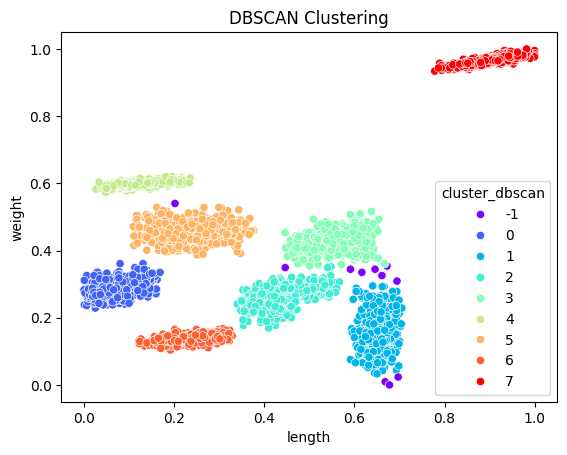

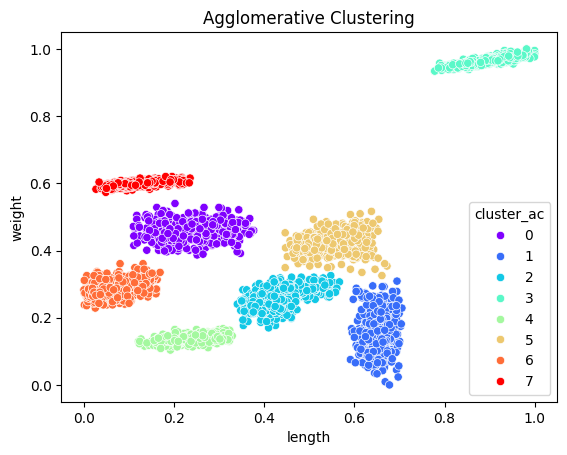

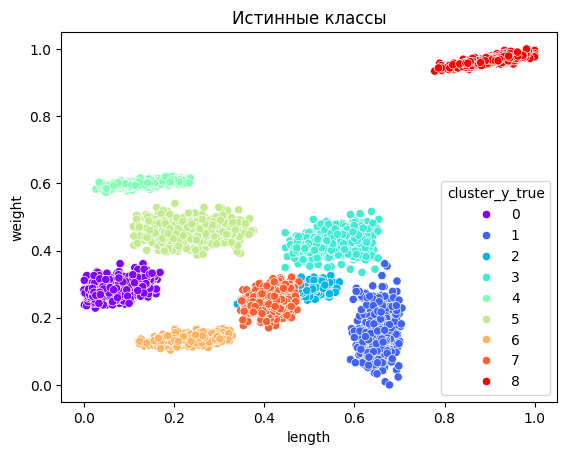

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

scaler_data['cluster_dbscan'] = dbscan.labels_
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_dbscan',
    palette="rainbow",
    legend='full'
)
plt.title("DBSCAN Clustering")
plt.show()


scaler_data['cluster_ac'] = model_ac.labels_
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_ac',
    palette="rainbow",
    legend='full'
)
plt.title("Agglomerative Clustering")
plt.show()

scaler_data['cluster_y_true'] = y_true
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_y_true',
    palette="rainbow",
    legend='full'
)
plt.title("Истинные классы")
plt.show()


Оба метода кластеризации — DBSCAN и агломеративная кластеризация — выявили в данных чётко разделённые компактные группы объектов, что хорошо подтверждается визуализацией в пространстве признаков (length, weight). Несмотря на различия алгоритмов, полученные кластеры почти полностью совпадают по форме и расположению с истинными метками. DBSCAN успешно выделил плотные группы и корректно определил несколько выбросов (обозначенных как «–1»), тогда как агломеративная кластеризация жёстко распределила все точки между кластерами, не выделяя шум. При этом структуру групп оба метода восстанавливают практически идентично: каждая группа представляет собой компактное облако с чёткими границами, что характерно для хорошо разделимых данных. Кластеры можно интерпретировать как объединения объектов со схожими значениями длины и веса: некоторые группы содержат небольшие и лёгкие объекты, другие — средние или более крупные. Такой характер распределения подтверждается и центрами кластеров (в случае K-means), которые располагаются в типичных зонах плотности данных и отражают среднее положение каждой группы. В целом, результаты показывают, что данные обладают ярко выраженной кластерной структурой, одинаково хорошо выявляемой разными методами, а отличие между алгоритмами заключается главным образом в обращении с шумом и выборе числа кластеров.